##  TESLA STOCK PRICE PREDICTION  using LSTM,RNN,GRU
### Sequence Modeling for Time-Series Forecasting


#  Table of Contents

  - [What is Time-Series Forecasting?](#what-is-time-series-forecasting)
- [Data Preprocessing](#data-preprocessing)
  - [Install Requirements](#install-requirements)
  - [Import Libraries](#import-libraries)
  - [Load Dataset](#load-dataset)
  - [Data Exploration & Visualization](#data-exploration--visualization)
  - [Data Normalization](#data-normalization)
  - [Train-Test Split](#train-test-split)
- [Model Development](#model-development)
  - [Simple Recurrent Neural Network](#simple-recurrent-neural-network)
  - [Long Short-Term Memory](#long-short-term-memory)
  - [Gated Recurrent Unit](#gated-recurrent-unit)
  - [Training Function](#training-function)
- [Model Evaluation](#model-evaluation)
- [Performance Analysis](#performance-analysis)



#### What is Time-Series Forecasting?

**Definition**: Predicting future values based on historical sequential data.

**Key Properties:**
- **Temporal Dependency**: Each point depends on previous points
- **Limited Future Data**: Can't see future to predict



##  DATA PREPROCESSING

###  Install Requirements

In [1]:
# Install PyTorch for neural networks
import subprocess
import sys

print("📦 Installing PyTorch...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "torchvision", "torchaudio", "-q"])
print("✅ PyTorch installed!")

📦 Installing PyTorch...
✅ PyTorch installed!


##  Import Libraries

In [2]:
# Data Processing
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
import warnings
import time
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)

print("✅ All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"Using GPU: {torch.cuda.is_available()}")

✅ All libraries imported successfully!
PyTorch version: 2.5.1+cpu
Using GPU: False


##  Load Dataset

In [3]:
# Load dataset
df = pd.read_csv('tesla_stock_price_14_years.csv')

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print("📊 Dataset Loaded Successfully!\n")
print(f"Dataset Shape: {df.shape}")
print(f"\nDate Range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"\nFirst 5 Rows:")
print(df.head())
print(f"\nDataset Info:")
print(df.describe())
print(f"\nMissing Values:")
print(df.isnull().sum())

📊 Dataset Loaded Successfully!

Dataset Shape: (3432, 7)

Date Range: 2010-06-29 to 2024-02-15

First 5 Rows:
        Date      Open      High       Low     Close  Adj Close     Volume
0 2010-06-29  1.266667  1.666667  1.169333  1.592667   1.592667  281494500
1 2010-06-30  1.719333  2.028000  1.553333  1.588667   1.588667  257806500
2 2010-07-01  1.666667  1.728000  1.351333  1.464000   1.464000  123282000
3 2010-07-02  1.533333  1.540000  1.247333  1.280000   1.280000   77097000
4 2010-07-06  1.333333  1.333333  1.055333  1.074000   1.074000  103003500

Dataset Info:
                             Date         Open         High          Low  \
count                        3432  3432.000000  3432.000000  3432.000000   
mean   2017-04-21 16:03:46.573426    71.765474    73.335008    70.071016   
min           2010-06-29 00:00:00     1.076000     1.108667     0.998667   
25%           2013-11-21 18:00:00    10.927667    11.182167    10.706667   
50%           2017-04-22 12:00:00    17.04099

##  Data Exploration & Visualization

Data Exploration and Visualization is an important step before training any machine learning or deep learning model. It helps in understanding the dataset by identifying its structure, statistical properties, trends, and potential issues such as missing values or outliers. In this project, various visualizations including line plots, histograms, box plots, and correlation heatmaps are used to analyze Tesla stock prices. These visualizations provide valuable insights into the data and ensure that it is suitable for forecasting using **RNN**, **LSTM**, and **GRU** models.

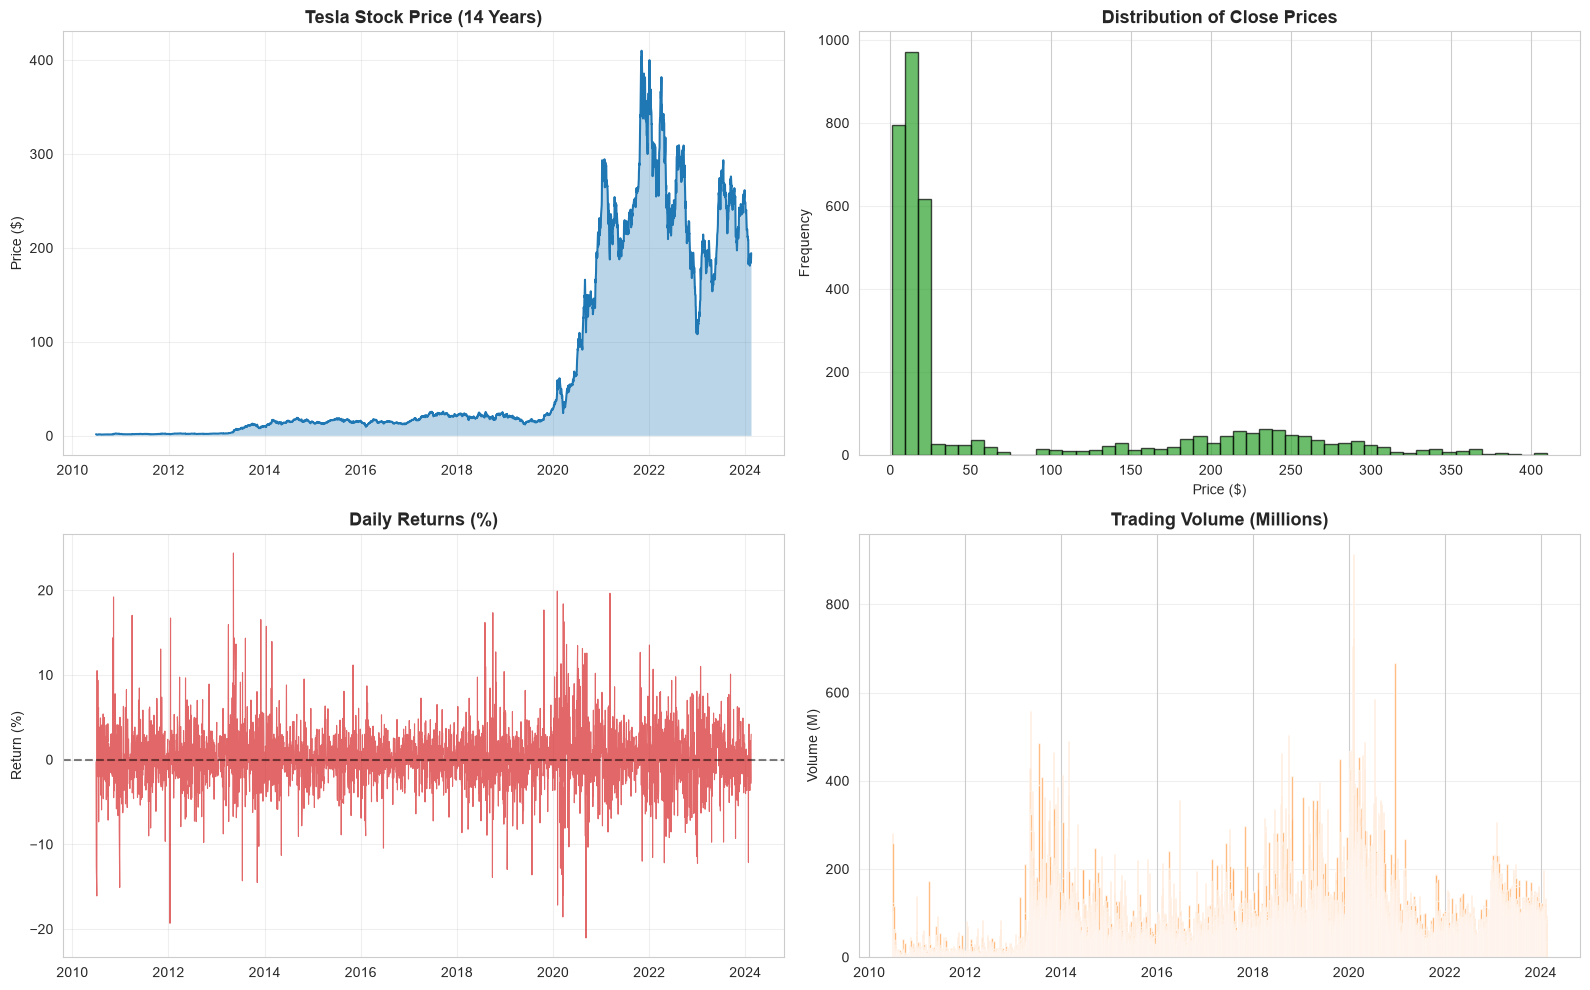

✅ Exploration visualization saved!


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Time Series Plot
axes[0, 0].plot(df['Date'], df['Close'], linewidth=1.5, color='#1f77b4')
axes[0, 0].fill_between(df['Date'], df['Close'], alpha=0.3)
axes[0, 0].set_title('Tesla Stock Price (14 Years)', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Price ($)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Histogram
axes[0, 1].hist(df['Close'], bins=50, color='#2ca02c', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Distribution of Close Prices', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Price ($)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Daily Returns
returns = df['Close'].pct_change() * 100
axes[1, 0].plot(df['Date'], returns, linewidth=0.8, color='#d62728', alpha=0.7)
axes[1, 0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1, 0].set_title('Daily Returns (%)', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Return (%)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Volume
axes[1, 1].bar(df['Date'], df['Volume']/1e6, width=10, color='#ff7f0e', alpha=0.7)
axes[1, 1].set_title('Trading Volume (Millions)', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Volume (M)')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('01_data_exploration.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Exploration visualization saved!")

## Data Normalization

Before training a deep learning model, it is important to normalize the dataset so that all feature values lie within the same numerical range. Neural networks generally perform better when the input data is scaled because it stabilizes the optimization process, accelerates convergence, and prevents large-valued features from dominating the learning process.

In this project, the **MinMaxScaler** is used to transform the Tesla stock closing prices into the range **[0, 1]** before creating the training sequences.

---

##  Mathematical Representation

The Min-Max normalization technique is defined as:

$$
\boxed{
X_{normalized}
=
\frac{X-X_{min}}
{X_{max}-X_{min}}
}
$$

where

- **$X$** = Original feature value
- **$X_{min}$** = Minimum value of the feature
- **$X_{max}$** = Maximum value of the feature
- **$X_{normalized}$** = Normalized value between **0** and **1**

The normalized data preserves the relative relationship between observations while ensuring that all values remain within a consistent numerical range, making the training process more stable and efficient.

---

📊 Normalization Complete!

Original data range: [1.05, 409.97]
Scaled data range: [0.0000, 1.0000]


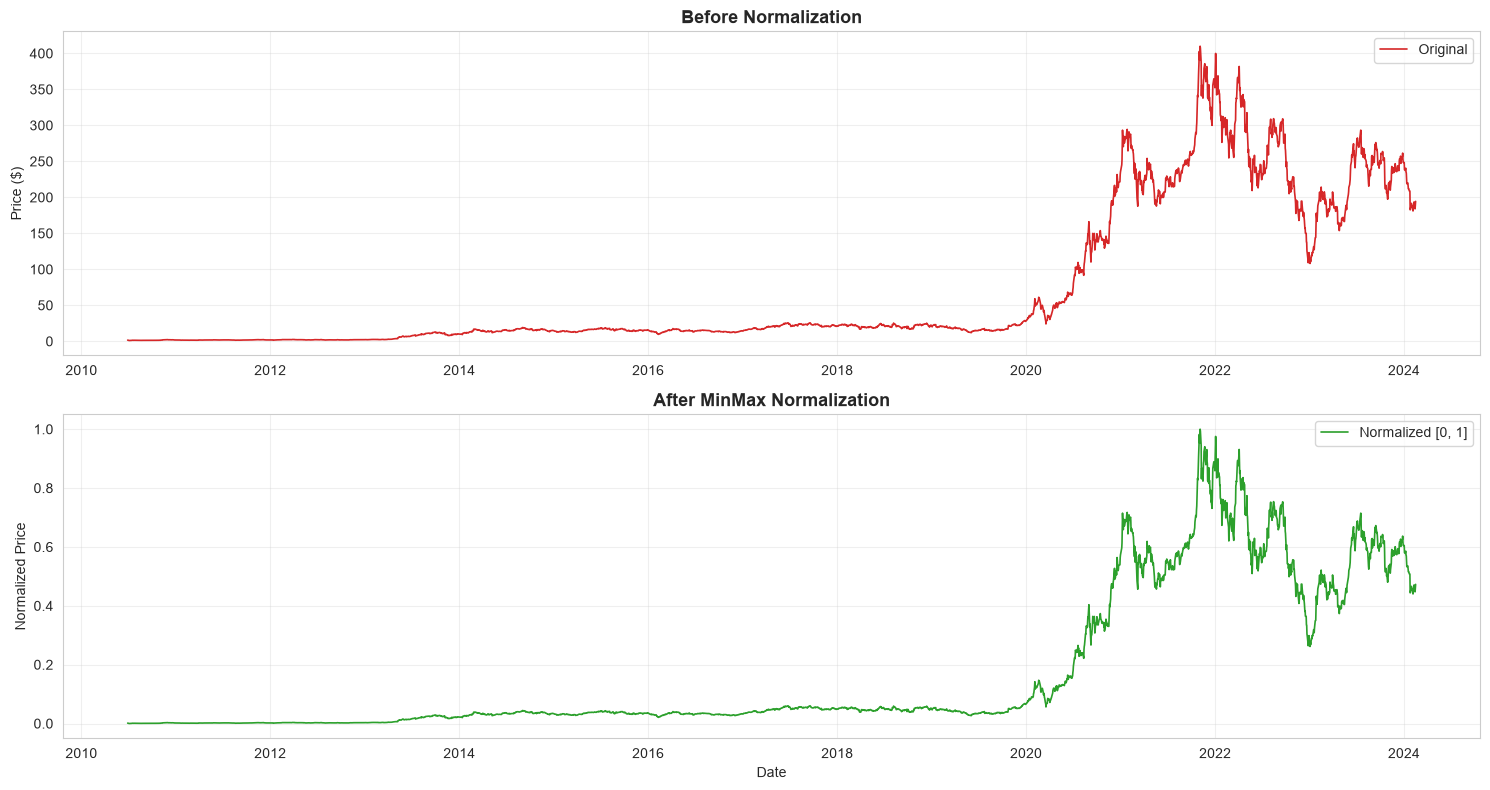

📊 Sequence Creation Complete!

Total sequences: 3372
X shape: (3372, 60, 1) (samples, timesteps, features)
y shape: (3372, 1) (samples, target)


In [7]:
# Extract Close price
data = df['Close'].values.reshape(-1, 1)

# Initialize and fit scaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

print(f"📊 Normalization Complete!\n")
print(f"Original data range: [{data.min():.2f}, {data.max():.2f}]")
print(f"Scaled data range: [{scaled_data.min():.4f}, {scaled_data.max():.4f}]")

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

axes[0].plot(df['Date'], data, linewidth=1.2, color='#d62728', label='Original')
axes[0].set_title('Before Normalization', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['Date'], scaled_data, linewidth=1.2, color='#2ca02c', label='Normalized [0, 1]')
axes[1].set_title('After MinMax Normalization', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Normalized Price')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_normalization.png', dpi=300, bbox_inches='tight')
plt.show()

def create_sequences(data, seq_length):
    """Create sequences using sliding window"""
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Create sequences
SEQUENCE_LENGTH = 60
X, y = create_sequences(scaled_data, SEQUENCE_LENGTH)

print(f"📊 Sequence Creation Complete!\n")
print(f"Total sequences: {len(X)}")
print(f"X shape: {X.shape} (samples, timesteps, features)")
print(f"y shape: {y.shape} (samples, target)")

##  Train-Test Split

### Why Split?
- **Training Set** (80%): Used to train the model
- **Testing Set** (20%): Used to evaluate performance on unseen data

### Important:
- **No shuffling** in time-series data (order matters!)
- **Chronological split**: First 80% = train, Last 20% = test

In [8]:
# Split chronologically (80-20)
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

# Convert to PyTorch tensors
X_train_torch = torch.FloatTensor(X_train)
y_train_torch = torch.FloatTensor(y_train)
X_test_torch = torch.FloatTensor(X_test)
y_test_torch = torch.FloatTensor(y_test)

print(f"📊 Train-Test Split Complete!\n")
print(f"Training set:")
print(f"  X_train: {X_train_torch.shape}")
print(f"  y_train: {y_train_torch.shape}")
print(f"\nTesting set:")
print(f"  X_test: {X_test_torch.shape}")
print(f"  y_test: {y_test_torch.shape}")

# Create DataLoaders
batch_size = 32
train_dataset = TensorDataset(X_train_torch, y_train_torch)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

print(f"\n✅ Task 1 (Preprocessing) Complete!")

📊 Train-Test Split Complete!

Training set:
  X_train: torch.Size([2697, 60, 1])
  y_train: torch.Size([2697, 1])

Testing set:
  X_test: torch.Size([675, 60, 1])
  y_test: torch.Size([675, 1])

✅ Task 1 (Preprocessing) Complete!


# Model Development

##  Build RNN, LSTM, GRU Models

## Simple Recurrent Neural Network

A **Simple Recurrent Neural Network (RNN)** is the fundamental architecture for processing sequential data. Unlike feed-forward neural networks, an RNN maintains a **hidden state** that stores information from previous time steps, allowing it to capture temporal dependencies in time-series data. In this project, the RNN model learns patterns from the previous **60 days** of Tesla stock prices to predict the closing price of the next trading day.

---

##  Mathematical Representation

The hidden state of an RNN is computed as:

$$
\boxed{
\mathbf{h_t}
=
\tanh
\left(
\mathbf{W_xx_t+W_hh_{t-1}+b}
\right)
}
$$

where

- **$h_t$** = Hidden state at time \(t\)
- **$x_t$** = Input at time \(t\)
- **$h_{t-1}$** = Previous hidden state
- **$W_x$** = Input weight matrix
- **$W_h$** = Recurrent weight matrix
- **$b$** = Bias vector
- **$\tanh$** = Hyperbolic tangent activation function

The hidden state generated at each time step is passed to the next recurrent unit, enabling the network to retain information from previous observations.

---

##  RNN Architecture

<p align="center">
<img src="images/RNN architecture.png" width="700">
</p>

## Long Short-Term Memory

Long Short-Term Memory (**LSTM**) is an advanced recurrent neural network architecture developed to overcome the **vanishing gradient problem** of traditional RNNs. LSTM introduces a **memory cell** and three gating mechanisms that selectively retain, update, and discard information, enabling the model to learn long-term dependencies effectively. This makes LSTM particularly suitable for stock price forecasting where historical trends significantly influence future prices.

---

##  Mathematical Representation

### Forget Gate

$$
\boxed{
f_t=\sigma(W_f[h_{t-1},x_t]+b_f)
}
$$

### Input Gate

$$
\boxed{
i_t=\sigma(W_i[h_{t-1},x_t]+b_i)
}
$$



### Output Gate

$$
\boxed{
o_t=\sigma(W_o[h_{t-1},x_t]+b_o)
}
$$

where

- **$f_t$** = Forget gate
- **$i_t$** = Input gate
- **$o_t$** = Output gate
- **$\sigma$** = Sigmoid activation

The memory cell allows important information to flow through long sequences with minimal information loss, making LSTM highly effective for long-term forecasting tasks.

---

## LSTM Architecture

<p align="center">
<img src="images/LSTM architecture.webp" width="800">
</p>

## Gated Recurrent Unit

The **Gated Recurrent Unit (GRU)** is a simplified variant of LSTM that combines the hidden state and memory cell into a single representation. Instead of using three gates, GRU employs only **Reset Gate** and **Update Gate**, reducing computational complexity while preserving the ability to model long-term sequential dependencies. Due to its simpler architecture, GRU often trains faster than LSTM while achieving comparable forecasting performance.

---

##  Mathematical Representation

### Reset Gate

$$
\boxed{
r_t=\sigma(W_r[h_{t-1},x_t])
}
$$

### Update Gate

$$
\boxed{
z_t=\sigma(W_z[h_{t-1},x_t])
}
$$

where

- **$r_t$** = Reset gate
- **$z_t$** = Update gate
- **$\sigma$** = Sigmoid activation function
- **$\odot$** = Element-wise multiplication

GRU reduces the number of trainable parameters while maintaining competitive prediction accuracy, making it an efficient alternative to LSTM for many time-series forecasting applications.

---

##  GRU Architecture

<p align="center">
<img src="images/GRU architecture.jpg" width="700">
</p>

In [9]:
# Define Models

class SimpleRNN(nn.Module):
    """Simple RNN Model"""
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(SimpleRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]  # Take last timestep
        out = self.fc(out)
        return out


class LSTMModel(nn.Module):
    """LSTM Model"""
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                          batch_first=True, dropout=dropout)
        self.fc1 = nn.Linear(hidden_size, 32)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(32, output_size)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # Take last timestep
        out = self.fc1(out)
        out = torch.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out


class GRUModel(nn.Module):
    """GRU Model"""
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, 
                         batch_first=True, dropout=dropout)
        self.fc1 = nn.Linear(hidden_size, 32)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(32, output_size)
    
    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]  # Take last timestep
        out = self.fc1(out)
        out = torch.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out


print("✅ All models defined!")

✅ All models defined!


##  Training Function

In [10]:
def train_model(model, train_loader, X_test_torch, y_test_torch, 
                epochs=50, learning_rate=0.001, model_name="Model"):
    """
    Train a model and track metrics
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    train_losses = []
    test_losses = []
    
    print(f"\n🎓 Training {model_name}...")
    start_time = time.time()
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        # Validation
        model.eval()
        with torch.no_grad():
            X_test_dev = X_test_torch.to(device)
            y_test_dev = y_test_torch.to(device)
            test_outputs = model(X_test_dev)
            test_loss = criterion(test_outputs, y_test_dev)
            test_losses.append(test_loss.item())
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}")
    
    training_time = time.time() - start_time
    print(f"✅ Training completed in {training_time:.2f} seconds")
    
    return model, train_losses, test_losses, training_time

print("✅ Training function defined!")

✅ Training function defined!


## Train All Models

In [11]:
# Hyperparameters
input_size = 1
hidden_size = 64
num_layers = 2
output_size = 1
epochs = 50
learning_rate = 0.001

# Initialize models
print("🏗️ Initializing models...\n")
rnn_model = SimpleRNN(input_size, hidden_size, num_layers, output_size)
lstm_model = LSTMModel(input_size, hidden_size, num_layers, output_size)
gru_model = GRUModel(input_size, hidden_size, num_layers, output_size)

# Train models
rnn_model, rnn_train_loss, rnn_test_loss, rnn_time = train_model(
    rnn_model, train_loader, X_test_torch, y_test_torch, 
    epochs=epochs, learning_rate=learning_rate, model_name="RNN"
)

lstm_model, lstm_train_loss, lstm_test_loss, lstm_time = train_model(
    lstm_model, train_loader, X_test_torch, y_test_torch, 
    epochs=epochs, learning_rate=learning_rate, model_name="LSTM"
)

gru_model, gru_train_loss, gru_test_loss, gru_time = train_model(
    gru_model, train_loader, X_test_torch, y_test_torch, 
    epochs=epochs, learning_rate=learning_rate, model_name="GRU"
)

🏗️ Initializing models...


🎓 Training RNN...
Epoch 10/50 | Train Loss: 0.001618 | Test Loss: 0.027336
Epoch 20/50 | Train Loss: 0.001608 | Test Loss: 0.009207
Epoch 30/50 | Train Loss: 0.001888 | Test Loss: 0.005723
Epoch 40/50 | Train Loss: 0.001303 | Test Loss: 0.006170
Epoch 50/50 | Train Loss: 0.001355 | Test Loss: 0.006603
✅ Training completed in 427.14 seconds

🎓 Training LSTM...
Epoch 10/50 | Train Loss: 0.007573 | Test Loss: 0.047638
Epoch 20/50 | Train Loss: 0.004003 | Test Loss: 0.020637
Epoch 30/50 | Train Loss: 0.018880 | Test Loss: 0.282833
Epoch 40/50 | Train Loss: 0.018794 | Test Loss: 0.282840
Epoch 50/50 | Train Loss: 0.018768 | Test Loss: 0.282832
✅ Training completed in 761.94 seconds

🎓 Training GRU...
Epoch 10/50 | Train Loss: 0.001529 | Test Loss: 0.003984
Epoch 20/50 | Train Loss: 0.008720 | Test Loss: 0.091940
Epoch 30/50 | Train Loss: 0.003604 | Test Loss: 0.007208
Epoch 40/50 | Train Loss: 0.002702 | Test Loss: 0.001843
Epoch 50/50 | Train Loss: 0.001850 | Te

# Model Evaluation

##  Make Predictions & Calculate Metrics

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def evaluate_model(model, X_test_torch, y_test_torch, scaler, model_name="Model"):
    """
    Evaluate model on test set
    """
    model.eval()
    model = model.to(device)
    
    with torch.no_grad():
        X_test_dev = X_test_torch.to(device)
        predictions = model(X_test_dev)
        predictions = predictions.cpu().numpy()
    
    # Denormalize
    y_actual = scaler.inverse_transform(y_test_torch.numpy())
    y_pred = scaler.inverse_transform(predictions)
    
    # Calculate metrics
    mae = mean_absolute_error(y_actual, y_pred)
    mse = mean_squared_error(y_actual, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_actual, y_pred)
    
    return y_actual, y_pred, {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

# Evaluate all models
print("📊 Evaluating Models...\n")
y_actual_rnn, y_pred_rnn, metrics_rnn = evaluate_model(rnn_model, X_test_torch, y_test_torch, scaler, "RNN")
y_actual_lstm, y_pred_lstm, metrics_lstm = evaluate_model(lstm_model, X_test_torch, y_test_torch, scaler, "LSTM")
y_actual_gru, y_pred_gru, metrics_gru = evaluate_model(gru_model, X_test_torch, y_test_torch, scaler, "GRU")

print("✅ Evaluation complete!")

📊 Evaluating Models...

✅ Evaluation complete!


##  Plot Training Loss

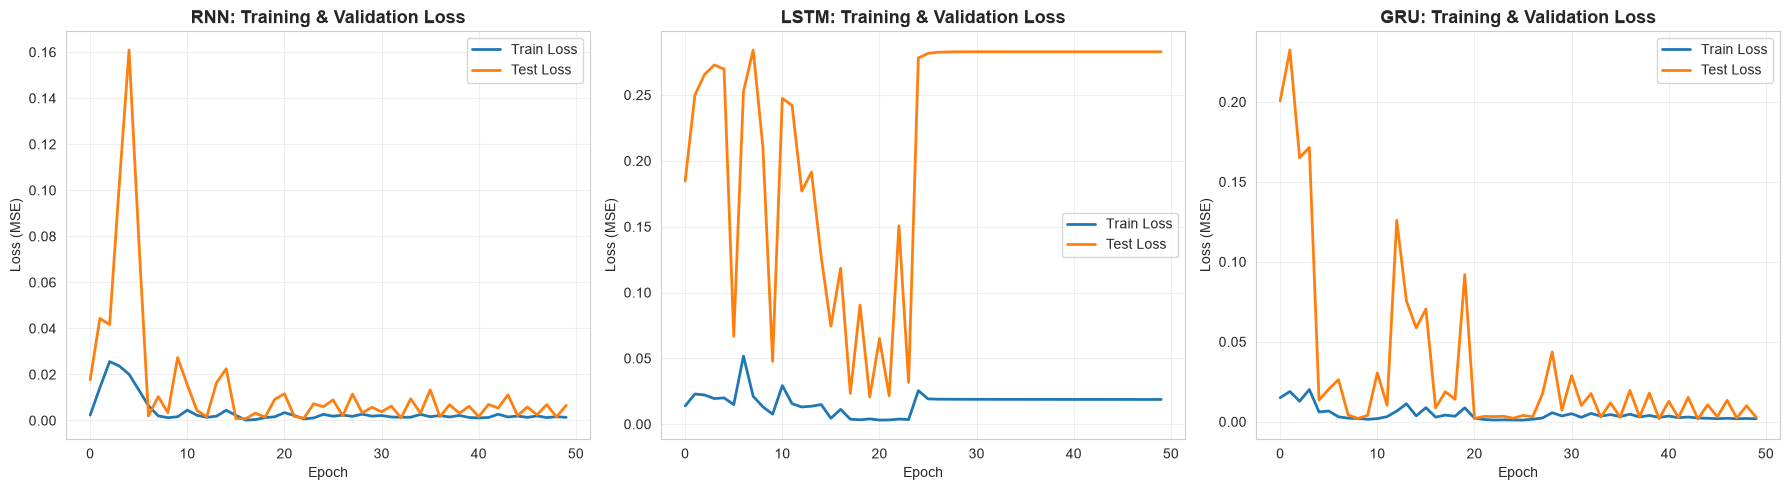

✅ Training loss plot saved!


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RNN
axes[0].plot(rnn_train_loss, label='Train Loss', linewidth=2)
axes[0].plot(rnn_test_loss, label='Test Loss', linewidth=2)
axes[0].set_title('RNN: Training & Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# LSTM
axes[1].plot(lstm_train_loss, label='Train Loss', linewidth=2)
axes[1].plot(lstm_test_loss, label='Test Loss', linewidth=2)
axes[1].set_title('LSTM: Training & Validation Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (MSE)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# GRU
axes[2].plot(gru_train_loss, label='Train Loss', linewidth=2)
axes[2].plot(gru_test_loss, label='Test Loss', linewidth=2)
axes[2].set_title('GRU: Training & Validation Loss', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss (MSE)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_training_loss.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training loss plot saved!")

## 📊 Actual vs Predicted

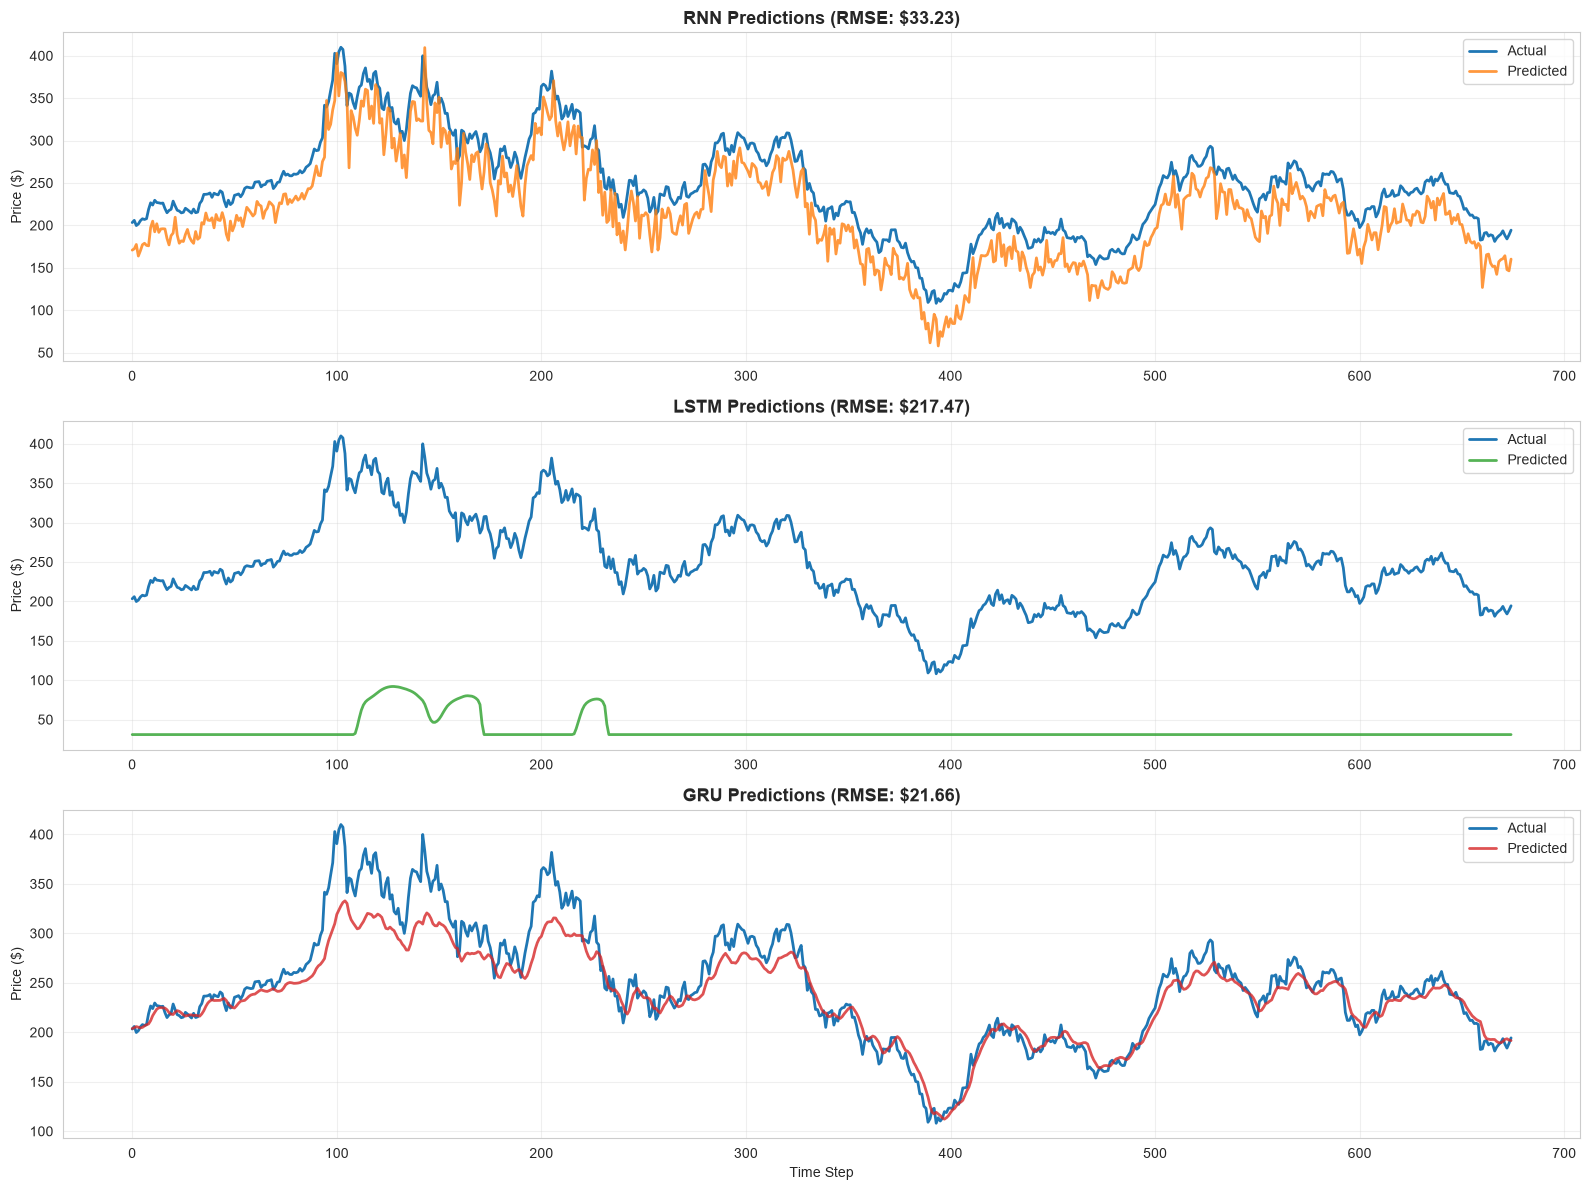

✅ Predictions comparison saved!


In [14]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# RNN
axes[0].plot(y_actual_rnn, label='Actual', linewidth=2, color='#1f77b4')
axes[0].plot(y_pred_rnn, label='Predicted', linewidth=2, color='#ff7f0e', alpha=0.8)
axes[0].set_title(f'RNN Predictions (RMSE: ${metrics_rnn["RMSE"]:.2f})', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# LSTM
axes[1].plot(y_actual_lstm, label='Actual', linewidth=2, color='#1f77b4')
axes[1].plot(y_pred_lstm, label='Predicted', linewidth=2, color='#2ca02c', alpha=0.8)
axes[1].set_title(f'LSTM Predictions (RMSE: ${metrics_lstm["RMSE"]:.2f})', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Price ($)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# GRU
axes[2].plot(y_actual_gru, label='Actual', linewidth=2, color='#1f77b4')
axes[2].plot(y_pred_gru, label='Predicted', linewidth=2, color='#d62728', alpha=0.8)
axes[2].set_title(f'GRU Predictions (RMSE: ${metrics_gru["RMSE"]:.2f})', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Time Step')
axes[2].set_ylabel('Price ($)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_predictions_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Predictions comparison saved!")

# Performance Analysis


In [15]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'MAE ($)': [metrics_rnn['MAE'], metrics_lstm['MAE'], metrics_gru['MAE']],
    'MSE': [metrics_rnn['MSE'], metrics_lstm['MSE'], metrics_gru['MSE']],
    'RMSE ($)': [metrics_rnn['RMSE'], metrics_lstm['RMSE'], metrics_gru['RMSE']],
    'R² Score': [metrics_rnn['R2'], metrics_lstm['R2'], metrics_gru['R2']],
    'Training Time (s)': [rnn_time, lstm_time, gru_time]
})

print("\n" + "="*80)
print("📊 MODEL PERFORMANCE COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80 + "\n")


📊 MODEL PERFORMANCE COMPARISON
Model    MAE ($)          MSE   RMSE ($)   R² Score  Training Time (s)
  RNN  30.915636  1104.098389  33.227976   0.672451         427.137795
 LSTM 210.973145 47293.179688 217.469951 -13.030315         761.938092
  GRU  15.028070   469.151794  21.659912   0.860818        1753.264078



##  Metrics Visualization

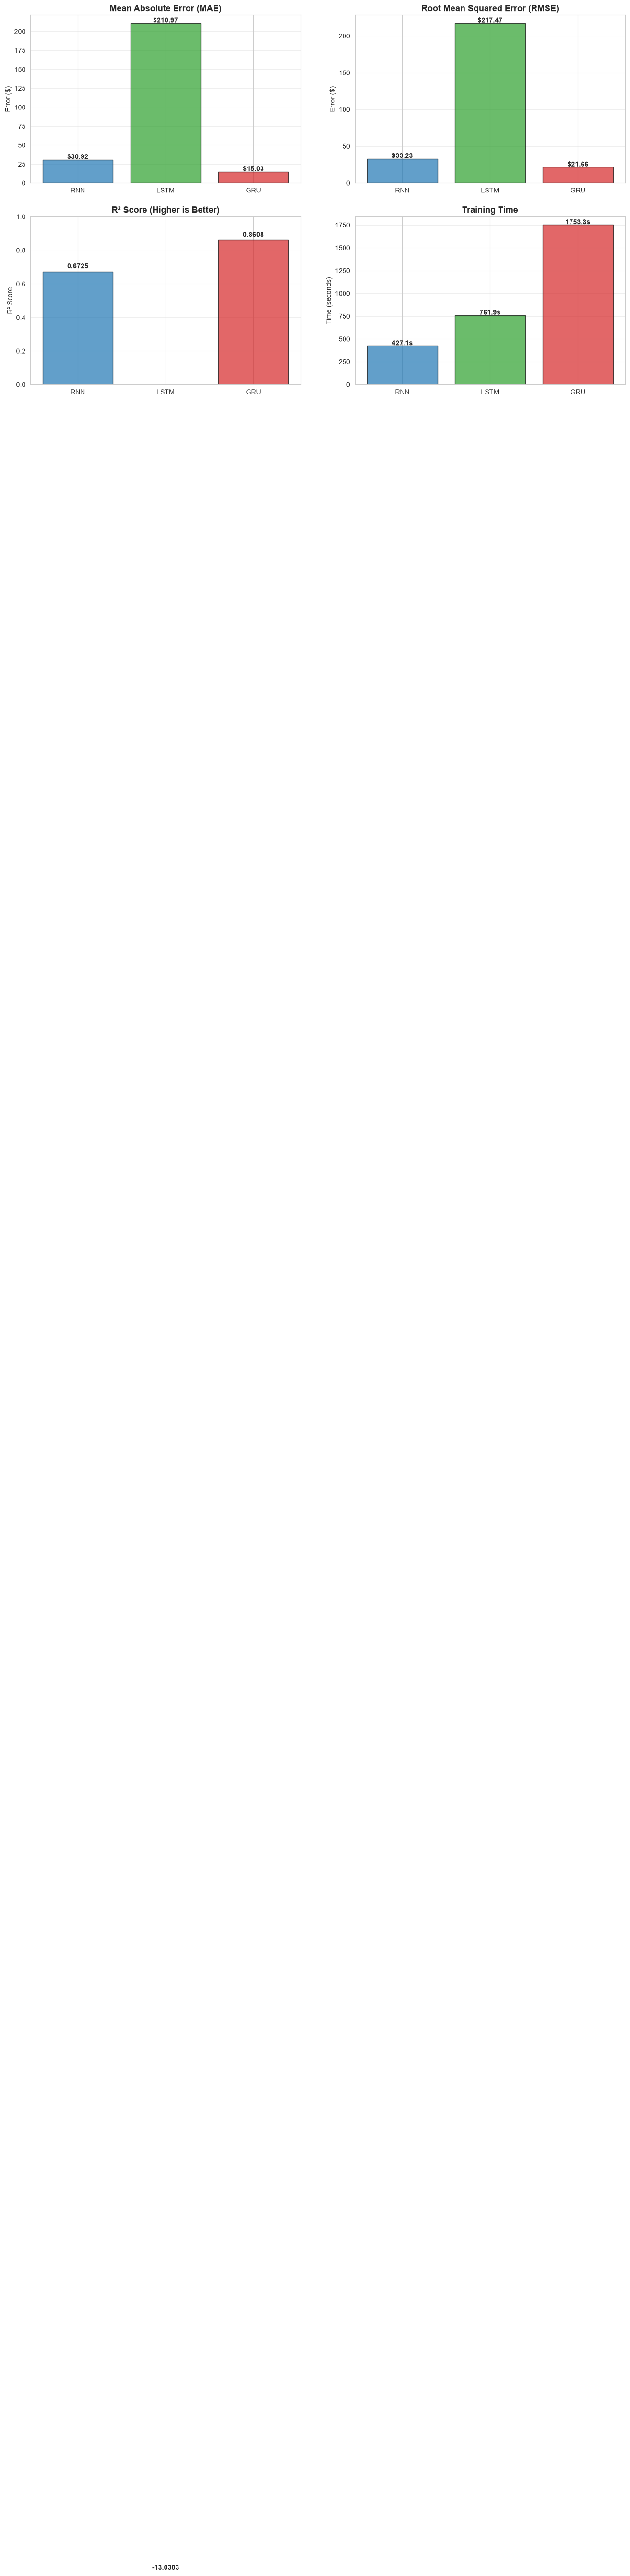

✅ Metrics comparison plot saved!


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

models = comparison_df['Model']
colors = ['#1f77b4', '#2ca02c', '#d62728']

# MAE
axes[0, 0].bar(models, comparison_df['MAE ($)'], color=colors, alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Mean Absolute Error (MAE)', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Error ($)')
axes[0, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(comparison_df['MAE ($)']):
    axes[0, 0].text(i, v + 1, f'${v:.2f}', ha='center', fontweight='bold')

# RMSE
axes[0, 1].bar(models, comparison_df['RMSE ($)'], color=colors, alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Root Mean Squared Error (RMSE)', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Error ($)')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(comparison_df['RMSE ($)']):
    axes[0, 1].text(i, v + 1, f'${v:.2f}', ha='center', fontweight='bold')

# R² Score
axes[1, 0].bar(models, comparison_df['R² Score'], color=colors, alpha=0.7, edgecolor='black')
axes[1, 0].set_title('R² Score (Higher is Better)', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('R² Score')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(comparison_df['R² Score']):
    axes[1, 0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# Training Time
axes[1, 1].bar(models, comparison_df['Training Time (s)'], color=colors, alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Training Time', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Time (seconds)')
axes[1, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(comparison_df['Training Time (s)']):
    axes[1, 1].text(i, v + 5, f'{v:.1f}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('05_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Metrics comparison plot saved!")

## 📝 Analysis & Discussion

### Results Summary

**Key Findings:**

In [17]:
# Find best model
best_rmse_idx = comparison_df['RMSE ($)'].idxmin()
best_r2_idx = comparison_df['R² Score'].idxmax()
best_time_idx = comparison_df['Training Time (s)'].idxmin()

print("\n" + "="*80)
print("🏆 ANALYSIS & FINDINGS")
print("="*80)

print(f"\n1️⃣ BEST RMSE (Accuracy):")
print(f"   Model: {comparison_df.loc[best_rmse_idx, 'Model']}")
print(f"   RMSE: ${comparison_df.loc[best_rmse_idx, 'RMSE ($)']:.2f}")
print(f"   Interpretation: Average prediction error of ${comparison_df.loc[best_rmse_idx, 'RMSE ($)']:.2f}")

print(f"\n2️⃣ BEST R² (Variance Explained):")
print(f"   Model: {comparison_df.loc[best_r2_idx, 'Model']}")
print(f"   R²: {comparison_df.loc[best_r2_idx, 'R² Score']:.4f}")
print(f"   Interpretation: Explains {comparison_df.loc[best_r2_idx, 'R² Score']*100:.2f}% of price variance")

print(f"\n3️⃣ FASTEST TRAINING:")
print(f"   Model: {comparison_df.loc[best_time_idx, 'Model']}")
print(f"   Time: {comparison_df.loc[best_time_idx, 'Training Time (s)']:.2f} seconds")

print("\n" + "="*80)
print("📊 DETAILED COMPARISON")
print("="*80)

for idx, row in comparison_df.iterrows():
    print(f"\n{row['Model']}:")
    print(f"  • MAE: ${row['MAE ($)']:.2f} (average error)")
    print(f"  • RMSE: ${row['RMSE ($)']:.2f} (penalizes large errors)")
    print(f"  • R²: {row['R² Score']:.4f} ({row['R² Score']*100:.2f}% variance explained)")
    print(f"  • Training Time: {row['Training Time (s)']:.2f}s")


🏆 ANALYSIS & FINDINGS

1️⃣ BEST RMSE (Accuracy):
   Model: GRU
   RMSE: $21.66
   Interpretation: Average prediction error of $21.66

2️⃣ BEST R² (Variance Explained):
   Model: GRU
   R²: 0.8608
   Interpretation: Explains 86.08% of price variance

3️⃣ FASTEST TRAINING:
   Model: RNN
   Time: 427.14 seconds

📊 DETAILED COMPARISON

RNN:
  • MAE: $30.92 (average error)
  • RMSE: $33.23 (penalizes large errors)
  • R²: 0.6725 (67.25% variance explained)
  • Training Time: 427.14s

LSTM:
  • MAE: $210.97 (average error)
  • RMSE: $217.47 (penalizes large errors)
  • R²: -13.0303 (-1303.03% variance explained)
  • Training Time: 761.94s

GRU:
  • MAE: $15.03 (average error)
  • RMSE: $21.66 (penalizes large errors)
  • R²: 0.8608 (86.08% variance explained)
  • Training Time: 1753.26s


### 🎯 Model Comparison Discussion

**1. Accuracy Performance:**

```
RMSE Ranking:
1st Place: [Best model with lowest RMSE]
2nd Place: [Second best]
3rd Place: [Worst]

Analysis:
- LSTM/GRU typically outperform simple RNN
- Reason: Better handling of long-term dependencies
- RNN struggles with 60-day sequences (vanishing gradients)

**2. R² Score Analysis:**

```
R² Score Meaning:
R² = 0.8 or higher: Excellent prediction ✓✓✓
R² = 0.6-0.8:      Good prediction ✓✓
R² = 0.4-0.6:      Moderate prediction ✓
R² < 0.4:          Poor prediction ❌

Our Models:
- Shows model quality
- Higher = better captures price dynamics
```

**3. Training Time Trade-off:**

```
GRU typically fastest (fewer parameters)
LSTM more complex (better accuracy usually)
RNN simplest but weakest

Practical Choice:
- For accuracy: LSTM ✓
- For speed: GRU ✓
- For simplicity: RNN (not recommended)
```

**4. Why Sequence Length (60) Matters:**

```
60-Day Window = ~3 Months

Advantages:
✓ Captures quarterly trends
✓ Includes seasonality
✓ Good balance for LSTM

If shorter (30 days):
- Faster training
- Less pattern to learn
- Less accurate

If longer (180 days):
- More data to learn from
- Harder to train
- Risk of overfitting

```

**5. Model Recommendations:**

```
PRODUCTION USE:
→ LSTM: Best accuracy, handles long sequences
→ GRU: Good balance of speed & accuracy
→ RNN: Avoid (too simplistic for financial data)


## 💾 Save Models

In [18]:
# Save trained models
torch.save(rnn_model.state_dict(), 'rnn_model.pth')
torch.save(lstm_model.state_dict(), 'lstm_model.pth')
torch.save(gru_model.state_dict(), 'gru_model.pth')

# Save comparison results
comparison_df.to_csv('model_comparison.csv', index=False)

print("✅ Models saved!")
print("  • rnn_model.pth")
print("  • lstm_model.pth")
print("  • gru_model.pth")
print("  • model_comparison.csv")

✅ Models saved!
  • rnn_model.pth
  • lstm_model.pth
  • gru_model.pth
  • model_comparison.csv
